# Exploratory Data Analysis — FDA Adverse Event Signal Detector

This notebook explores the cleaned, feature-engineered FDA adverse event dataset (FAERS, accessed via the openFDA API [1,2]) ahead of model training. The data covers 23,173 unique reports across 15 target drugs spanning several therapeutic categories (pain/NSAID, diabetes, cardiovascular, mental health, opioid, antibiotic, thyroid).

FAERS is a spontaneous, voluntary reporting system: the presence of a report does not establish that a drug caused the event, and the data is subject to known limitations including underreporting, duplicate reports, reporting bias toward severe or novel events, and the absence of a defined denominator for calculating true incidence rates [1,2]. Additional documented biases include the "Weber effect" (reporting historically peaks around two years after a drug's approval) [3] and "stimulated reporting" (reporting spikes following FDA safety alerts or label changes) [4].

Data was fetched, deduplicated, and structured into a three-table relational schema (`reports`, `drugs`, `reactions`) in `src/build_database.py`, with two additional engineered features (`reaction_count`, `drug_count`) added via SQL in `src/feature_engineering.py`. This notebook picks up from that database.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Data

Connecting to the database and pulling the `reports` table into a dataframe for exploration.

In [21]:
conn = sqlite3.connect("../data/fda_adverse_events.db")
df = pd.read_sql_query("SELECT * FROM reports", conn)

In [7]:
df.head()

,safetyreportid,serious,seriousnessdeath,seriousnesshospitalization,seriousnessdisabling,seriousnesslifethreatening,patientonsetage,patientonsetageunit,patientsex,receivedate,reaction_count,drug_count
0,10003301,1,NaN,NaN,NaN,NaN,NaN,NaN,2,20140228,2,1
1,10003319,1,NaN,1,NaN,NaN,46.0,801,2,20140312,4,10
2,10003865,1,NaN,1,NaN,NaN,18.0,801,2,20140312,2,10
3,10004019,1,NaN,1,NaN,NaN,33.0,801,2,20140312,2,3
4,10004183,2,NaN,NaN,NaN,NaN,54.0,801,1,20140312,1,4


In [8]:
df.shape

(23173, 12)

In [18]:
df.describe()

,patientonsetage,reaction_count,drug_count
count,19084.000000,23173.000000,23173.000000
mean,110.226210,4.031114,8.174859
std,1104.830623,5.462774,8.029334
min,0.000000,1.000000,1.000000
25%,49.000000,1.000000,3.000000
50%,62.000000,3.000000,6.000000
75%,73.000000,5.000000,11.000000
max,33071.000000,200.000000,304.000000


In [19]:
df["patientonsetageunit"].value_counts()

patientonsetageunit
801    18827
804      104
802       81
800       61
803        9
805        2
Name: count, dtype: int64

In [22]:
df["patientonsetage_years"].describe()

count    19084.000000
mean        59.182417
std         18.799902
min          0.000000
25%         49.000000
50%         62.000000
75%         73.000000
max        102.000000
Name: patientonsetage_years, dtype: float64

## Class Balance: Serious Outcomes

Before looking at individual features, checking how reports are distributed between serious and non-serious outcomes.

In [9]:
df["serious"].dtype

<StringDtype(na_value=nan)>

In [10]:
serious_map = {"1": "Serious", "2": "Not Serious"}
df["serious_label"] = df["serious"].map(serious_map)

In [12]:
df["serious_label"].value_counts()

serious_label
Serious        18322
Not Serious     4851
Name: count, dtype: int64

<Axes: xlabel='serious_label', ylabel='count'>

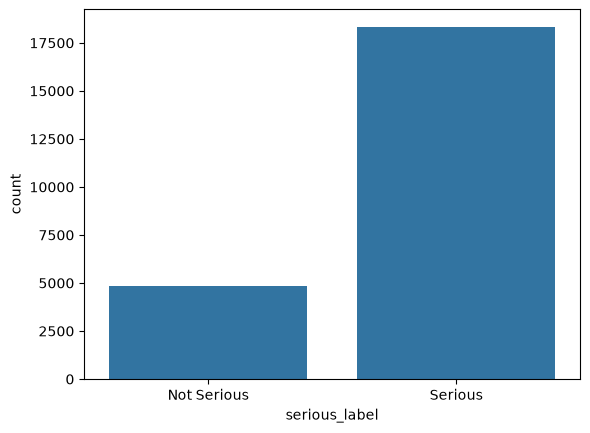

In [13]:
sns.countplot(data=df, x="serious_label", order=["Not Serious", "Serious"])

The dataset is visibly imbalanced toward serious outcomes: 18,322 reports (79%) are marked serious, compared to 4,851 (21%) not serious. This is a meaningfully different balance than a typical clinical dataset, likely reflecting known reporting biases in FAERS, where more severe/novel events are more likely to be reported, as opposed to non-serious outcomes [1,2].

This imbalance will need to be accounted for during modeling. A model could achieve high accuracy simply by always predicting "Serious," without actually learning anything useful. Precision, recall and class-specific metrics will matter more than overall accuracy.

## Reaction Count and Drug Count Distributions

Looking at the two engineered features before checking their relationship to seriousness.

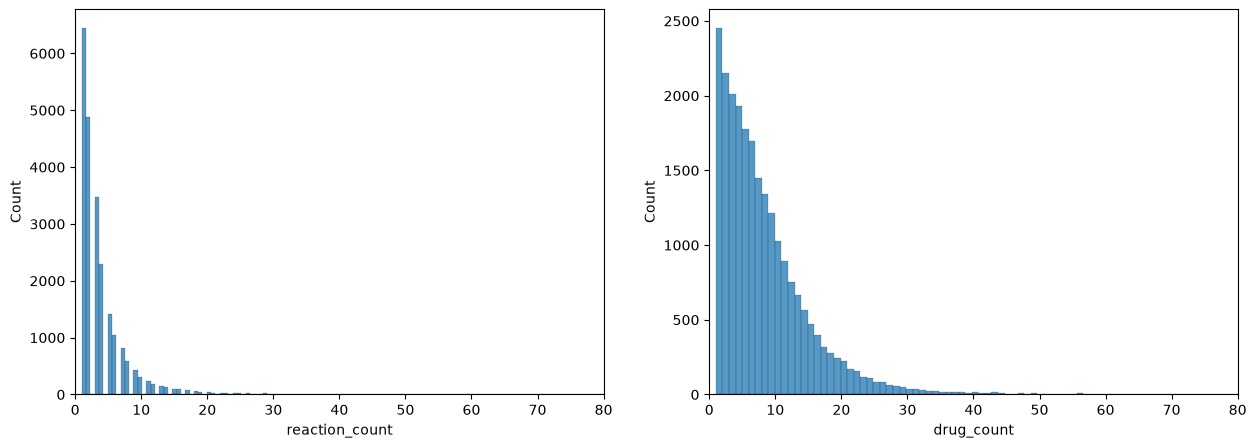

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=df, x="reaction_count", ax=axes[0])
axes[0].set_xlim(0, 80)
sns.histplot(data=df, x="drug_count", ax=axes[1])
axes[1].set_xlim(0, 80)
plt.show()

Both reaction_count and drug_count are strongly right-skewed. Zooming into 0-80 shows the shape clearly: reaction_count drops off sharply, with the large majority of reports listing fewer than 10 reactions. drug_count has a noticeably wider spread, declining more gradually out toward 30-40 before thinning out. A small number of reports fall well outside this range entirely (over 175 reactions in one case, over 300 drugs in another), not visible in this zoomed view.

This kind of long tail is common in real-world count data and is worth keeping in mind for modeling: a few extreme reports could disproportionately influence a model that isn't robust to outliers, and it may be worth considering a transformation (e.g. log scale) or capping extreme values later if this skew causes issues.

Reports with unusually high drug_count in particular likely reflect complex, multi-drug cases (polypharmacy) or possibly manufacturer-submitted bulk reports rather than typical single-patient adverse events — worth investigating further if time allows.